In [1]:
#　今回予測したいもの　→　販売価格(SalePrice)
#  1.予測対象の変数（目的変数）の把握 分布、外れ値、ゆがみなどを調べる

#　2.どんな特徴量があるか?

#　3.各特徴量の分布や異常値、偏りなどを確認

In [2]:
# ライブラリの読み込み
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# 全部コラムを見たい場合 → pd.set_option("display.max_columns", None)

# データの読み込み
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")



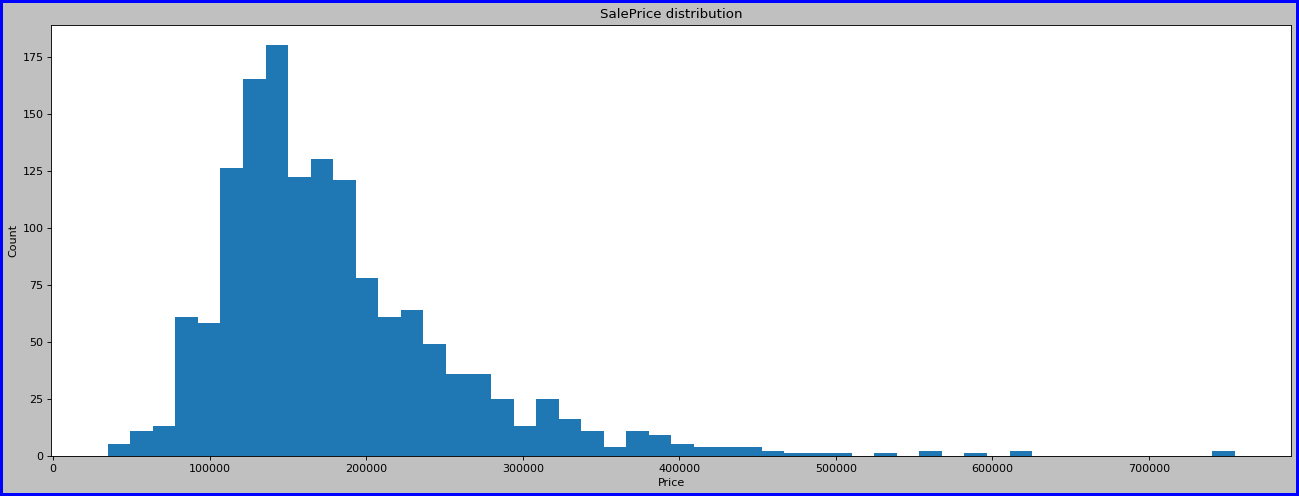

In [3]:
# 1.データの確認

# figsize	枠組みのサイズ、float値で(width, height)を指定
# dpi	解像度を整数で指定
# facecolor	背景色を指定、16 進数のカラーコードも指定可
# edgecolor	枠の色を指定、b は "Blue"の省略
# linewidth	枠線の太さを指定、整数
fig = plt.figure(figsize=(20,7), dpi=80, facecolor='silver', edgecolor='b',linewidth=5)

plt.hist(train["SalePrice"], bins=50)
plt.title("SalePrice distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [4]:
# グラフの右側の異常に高い価格帯の詳細を見てみる。（外れ値の確認）
train["SalePrice"].sort_values(ascending=False).head()

691     755000
1182    745000
1169    625000
898     611657
803     582933
Name: SalePrice, dtype: int64

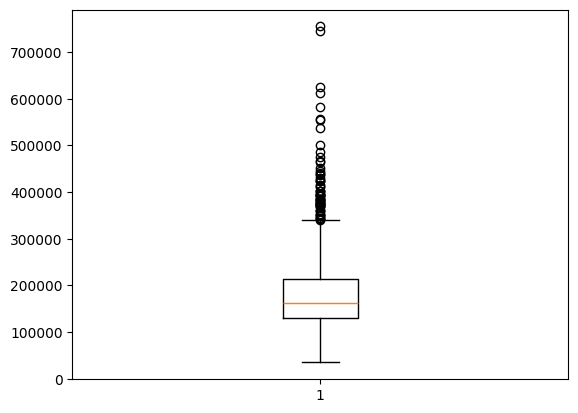

In [5]:
# 異常に高い価格帯や低い価格帯の住宅を見てみる。
# 1.箱の範囲はQ1-Q3で25%-75% (全データの50%) 2.オレンジの線がQ2でMedian(中央値) 3.ひげは最大値と最小値 4.○は外れ値

plt.boxplot(train["SalePrice"])
plt.show()

<Axes: xlabel='SalePrice', ylabel='Count'>

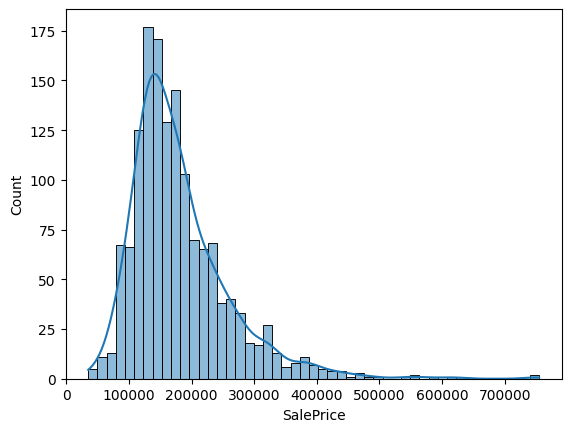

In [6]:
# Seabornを使ってゆがみの可視化を行う。
# KEDとはKernel Density Estimation(確率密度曲線) つまり、分布を滑らかな曲線で表現
sns.histplot(train["SalePrice"], kde=True)

<Axes: xlabel='SalePrice', ylabel='Density'>

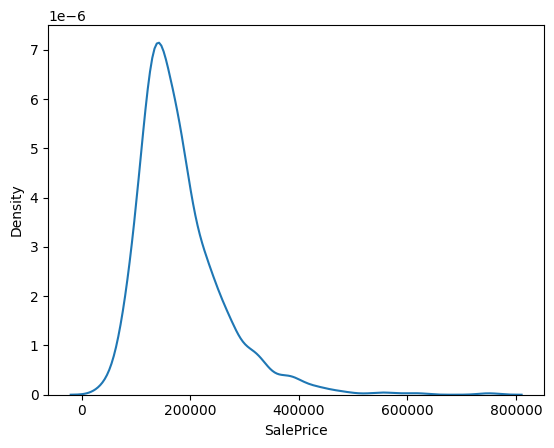

In [7]:
# 見やすく線だけにする場合
sns.kdeplot(train["SalePrice"])

<Axes: xlabel='SalePrice', ylabel='Count'>

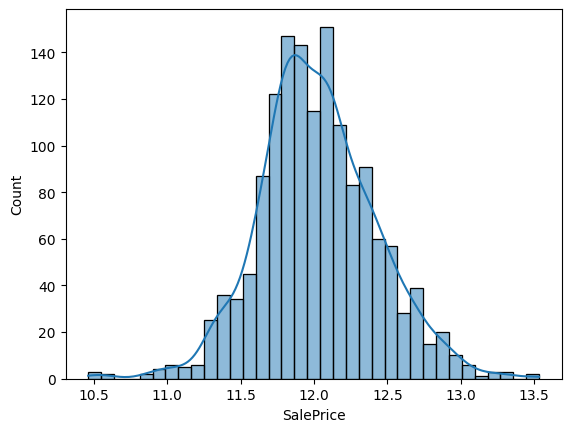

In [8]:
# log変換(対数変換)を行う。
# 多くのデータは **右に歪んだ分布（skewed distribution）**になっています。　例：住宅価格、収入、売り上げ、人口など
# log変換すると 1.分布を正規分布に近づけられる。 2.外れ値の影響を小さくできる 3.モデルが学習しやすくなる。
sns.histplot(np.log1p(train["SalePrice"]), kde=True)

In [9]:
# 2.どんな特徴量があるかを調べる。
train.columns


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [10]:
# データの種類ごとに分けてみる。
# 例:面積・築年数は数値。 地域や屋根タイプはカテゴリ。 販売年は日付など
train.dtypes


Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [11]:
#数値特徴量の抽出(数値データのみ取り出す。 ※そのまま使える)
num_cols = train.select_dtypes(include=["int64","float64"]).columns

print(len(num_cols))
print(num_cols)

38
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')


In [12]:
# カテゴリ特徴量の抽出(文字列などの分類データのみ取り出す。※数値変換が必要)
cat_cols = train.select_dtypes(include=["object"]).columns

print(len(cat_cols))
print(cat_cols)

43
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [13]:
# カテゴリ特徴量のユニーク数
# 例えば地域という特徴量で、このデータでは25種類の地域を扱っている。などという意味
for col in cat_cols:
    print(col, train[col].nunique())

MSZoning 5
Street 2
Alley 2
LotShape 4
LandContour 4
Utilities 2
LotConfig 5
LandSlope 3
Neighborhood 25
Condition1 9
Condition2 8
BldgType 5
HouseStyle 8
RoofStyle 6
RoofMatl 8
Exterior1st 15
Exterior2nd 16
MasVnrType 3
ExterQual 4
ExterCond 5
Foundation 6
BsmtQual 4
BsmtCond 4
BsmtExposure 4
BsmtFinType1 6
BsmtFinType2 6
Heating 6
HeatingQC 5
CentralAir 2
Electrical 5
KitchenQual 4
Functional 7
FireplaceQu 5
GarageType 6
GarageFinish 3
GarageQual 5
GarageCond 5
PavedDrive 3
PoolQC 3
Fence 4
MiscFeature 4
SaleType 9
SaleCondition 6


In [14]:
# 全体的にデータの構造をみる。

train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [15]:
# データの統計情報
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


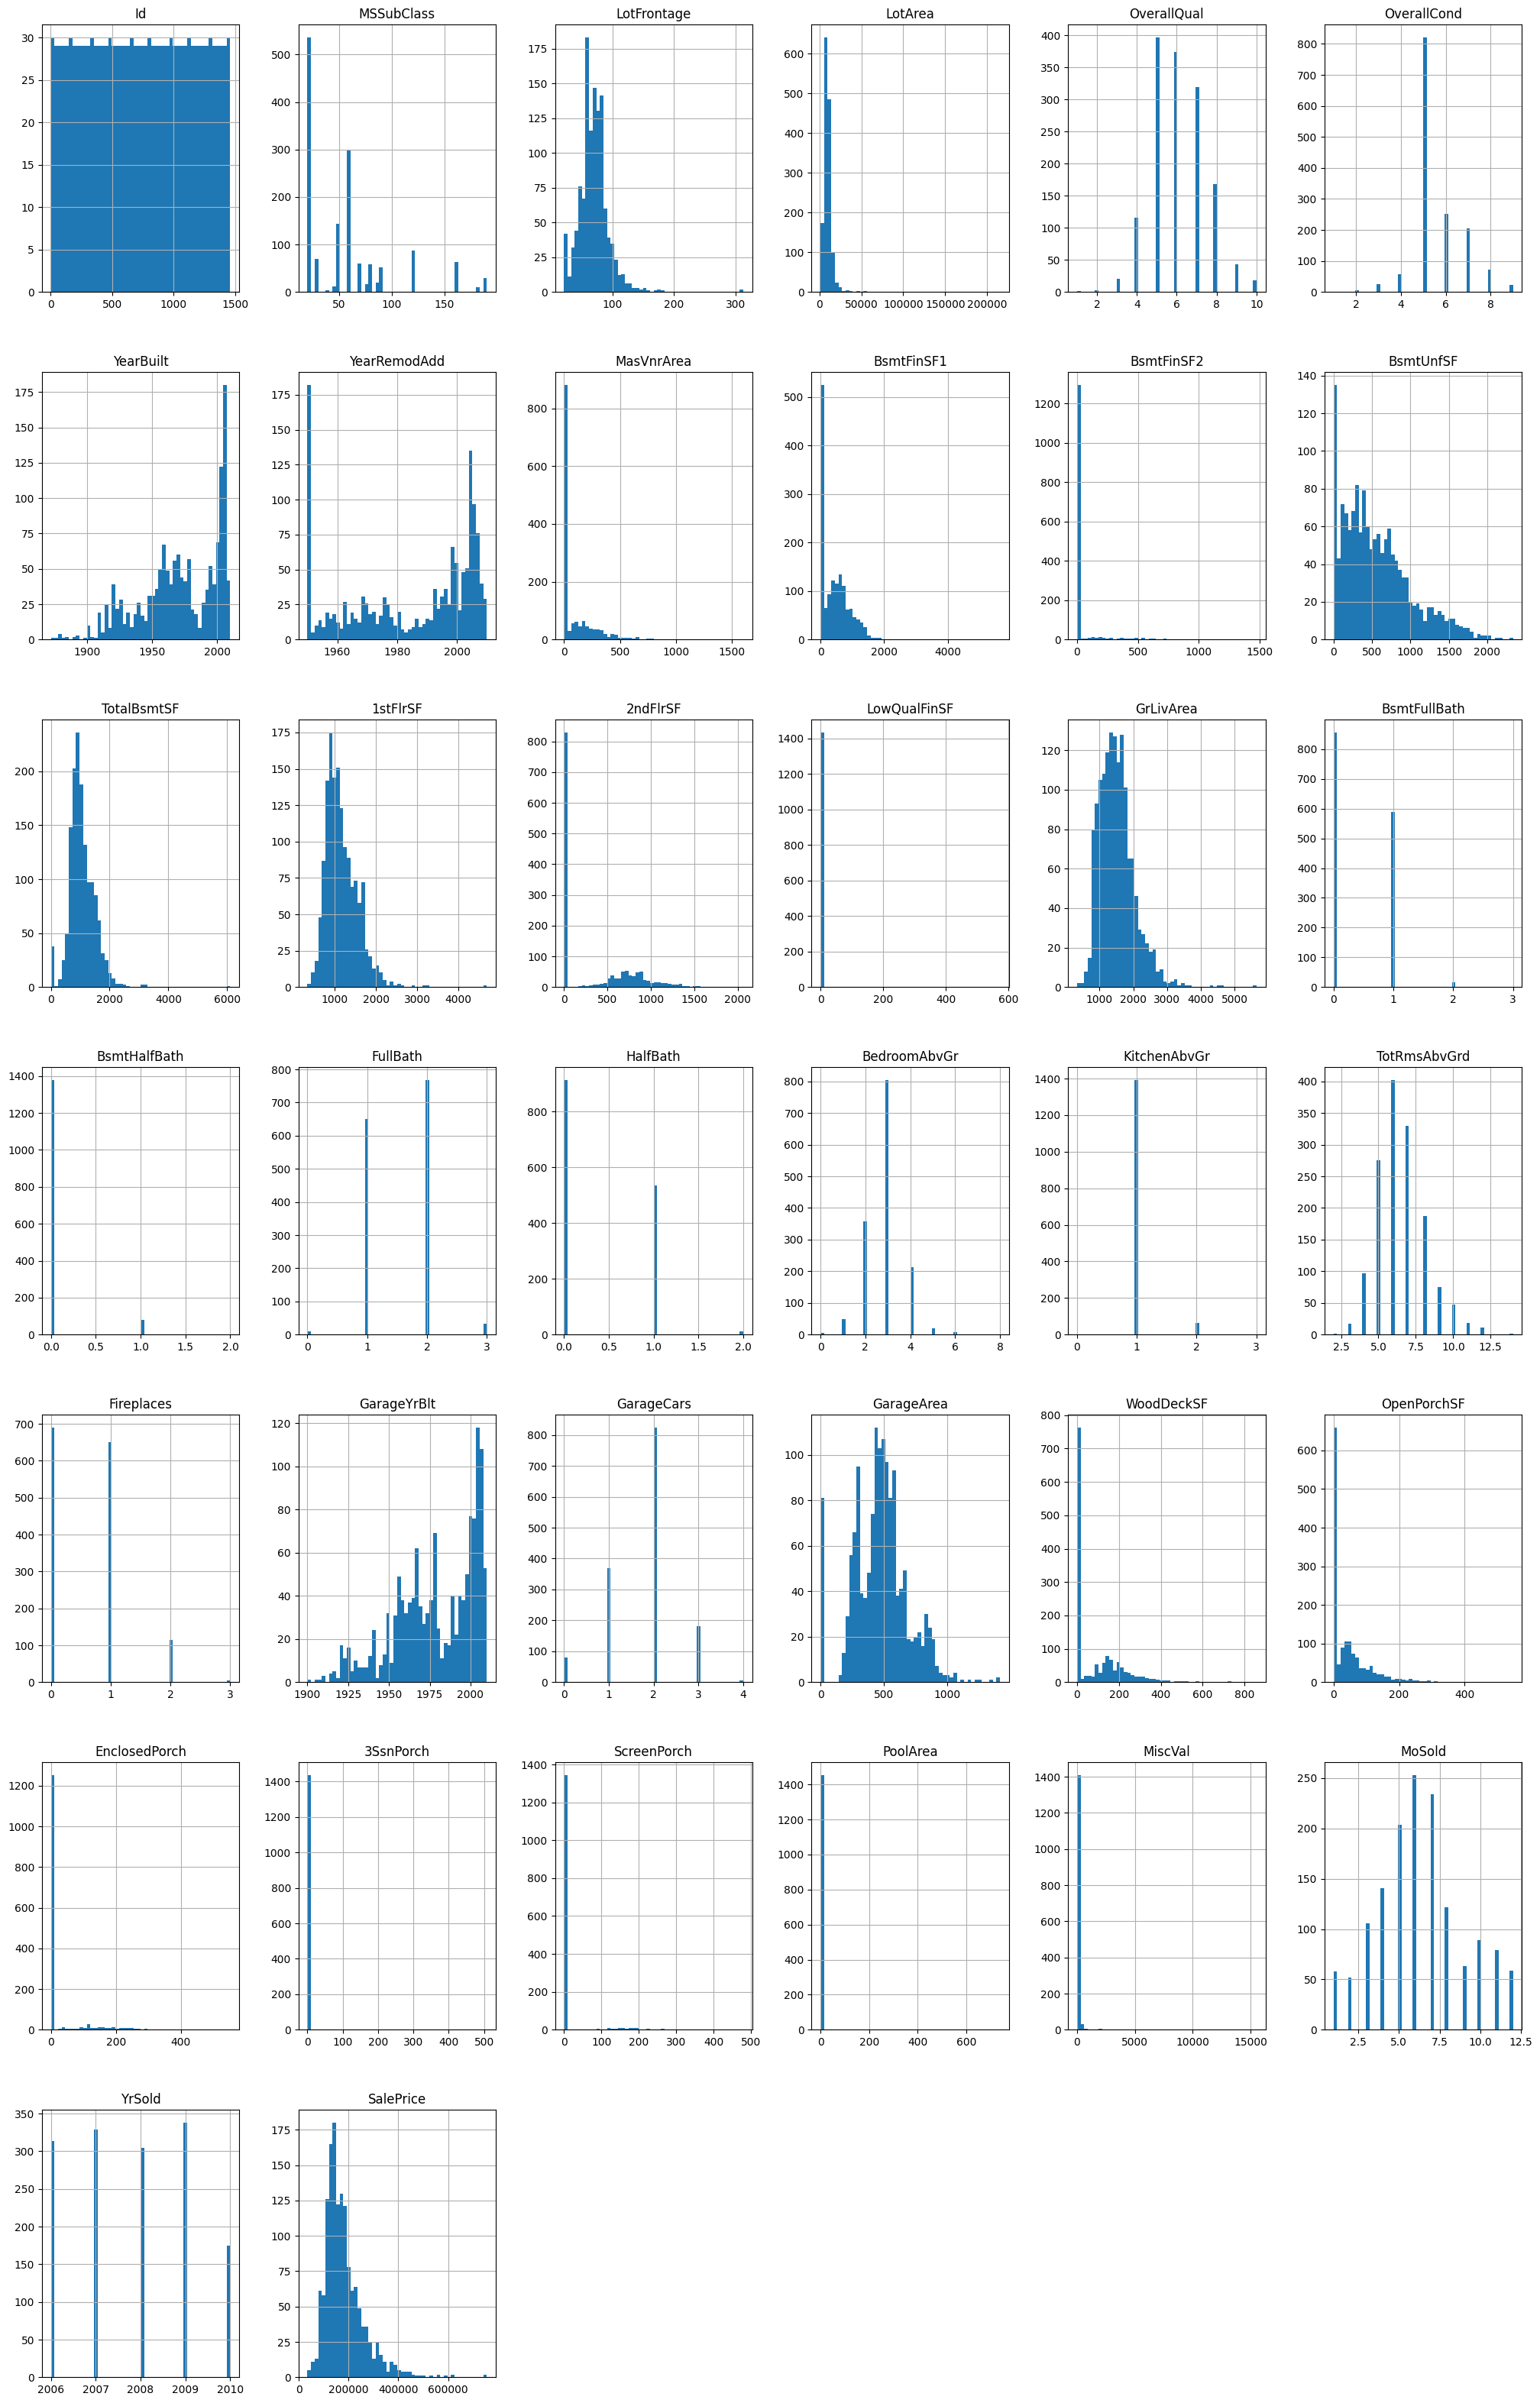

In [16]:
# 3.各特徴量の分布や異常値、偏りなどを確認する。
train[num_cols].hist(figsize=(25,40), bins=50)

plt.show()

In [17]:
# 欠損値の確認
train.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

<Axes: >

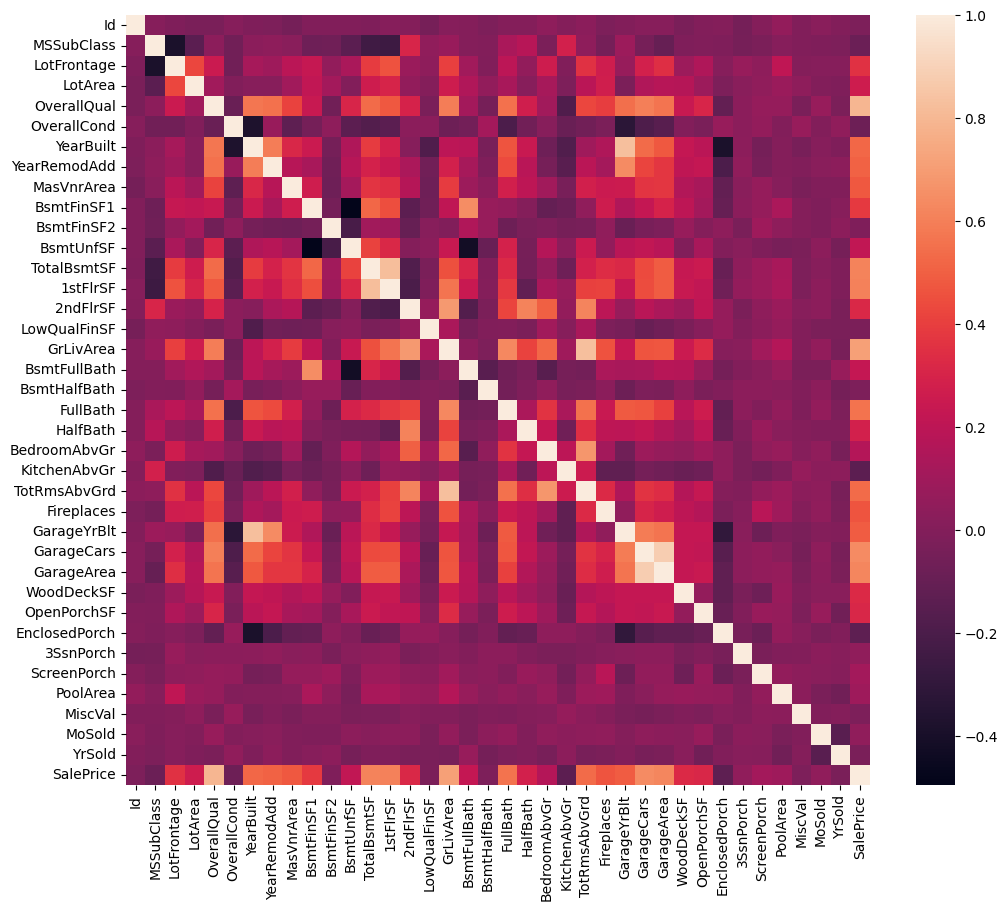

In [21]:
# 5-3,EDA(相関)
corr = train.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr)



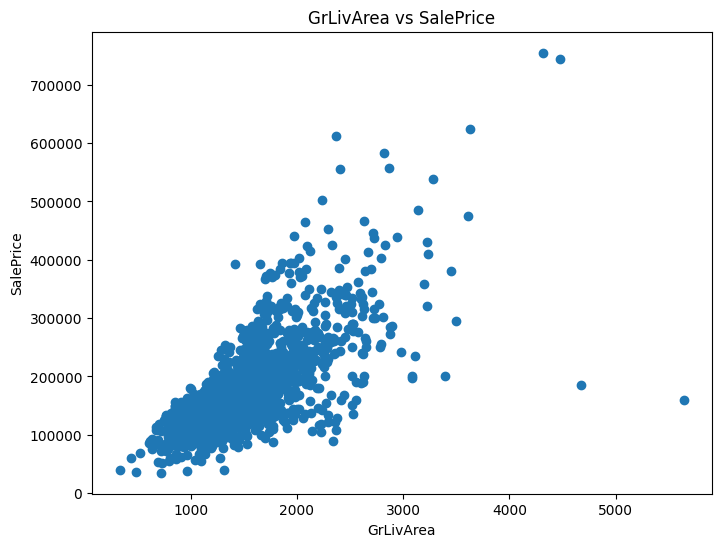

In [22]:
# 5-4,matplotlibによる散布図(価格VS面積)
plt.figure(figsize=(8,6))

plt.scatter(train["GrLivArea"], train["SalePrice"])

plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")

plt.show()

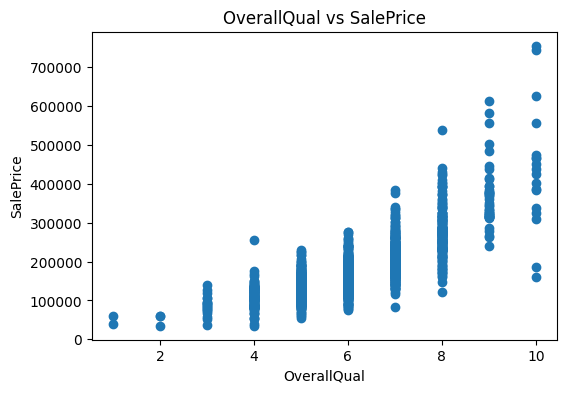

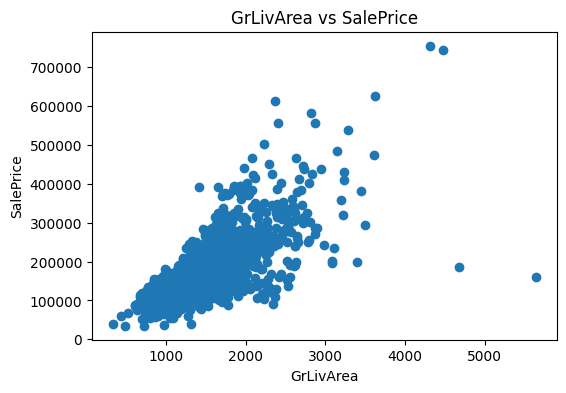

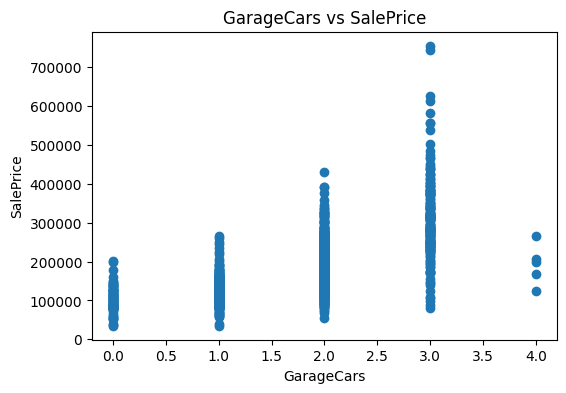

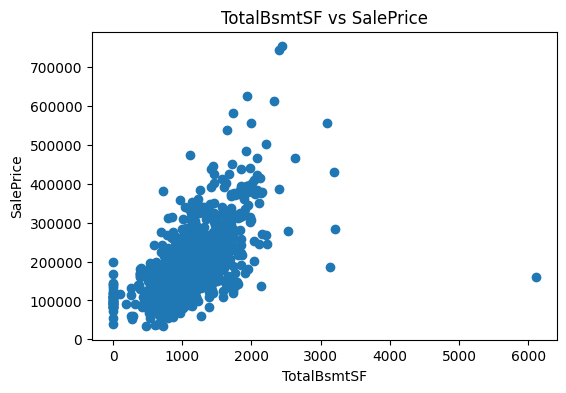

In [23]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF"
]

for f in features:

    plt.figure(figsize=(6,4))

    plt.scatter(train[f], train["SalePrice"])

    plt.title(f"{f} vs SalePrice")

    plt.xlabel(f)
    plt.ylabel("SalePrice")

    plt.show()